# Riot Churn - EDA

Train table only (`modeling/datasets/churn_train.csv`), per `modeling/01-data.md`. Feature cutoff day 120, label day 180 (60-day horizon).

In [1]:
import pandas as pd
df = pd.read_csv('../modeling/datasets/churn_train.csv')
print('shape:', df.shape)
df.head()

shape: (7224, 19)


,player_id,signup_day,region,platform,acquisition_source,tenure_at_scoring,active_days,total_games,total_wins,total_party_games,total_minutes,win_rate,days_since_last_active,activity_trend,total_spend,purchase_count,distinct_item_types,days_since_last_purchase,label
0,0,0,EUW,mobile,organic,120,61.0,139.0,68.0,83.0,4023.6,0.489209,36.0,-65.0,0.00,0.0,0.0,120.0,1
1,1,27,NaN,pc,organic,93,72.0,159.0,73.0,101.0,4388.6,0.459119,1.0,49.0,24.98,2.0,2.0,13.0,0
2,2,0,LATAM,pc,organic,120,105.0,249.0,123.0,163.0,7061.0,0.493976,2.0,-15.0,0.00,0.0,0.0,120.0,0
3,3,15,EUW,pc,organic,105,1.0,1.0,1.0,0.0,26.4,1.000000,105.0,-1.0,0.00,0.0,0.0,105.0,1
4,4,15,NaN,mobile,friend_referral,105,78.0,172.0,76.0,111.0,4852.9,0.441860,1.0,48.0,0.00,0.0,0.0,105.0,0


## Nulls

In [2]:
df.isna().mean().sort_values(ascending=False)

region                      0.295127
player_id                   0.000000
total_minutes               0.000000
days_since_last_purchase    0.000000
distinct_item_types         0.000000
purchase_count              0.000000
total_spend                 0.000000
activity_trend              0.000000
days_since_last_active      0.000000
win_rate                    0.000000
total_party_games           0.000000
signup_day                  0.000000
total_wins                  0.000000
total_games                 0.000000
active_days                 0.000000
tenure_at_scoring           0.000000
acquisition_source          0.000000
platform                    0.000000
label                       0.000000
dtype: float64

## Target balance

In [3]:
df['label'].value_counts(normalize=True)

label
1    0.665836
0    0.334164
Name: proportion, dtype: float64

## Numeric feature distributions

In [4]:
numeric_cols = ['tenure_at_scoring','active_days','total_games','total_wins','total_party_games','total_minutes','win_rate','days_since_last_active','activity_trend','total_spend','purchase_count','distinct_item_types','days_since_last_purchase']
df[numeric_cols].describe().T.assign(skew=df[numeric_cols].skew())

,count,mean,std,min,25%,50%,75%,max,skew
tenure_at_scoring,7224.0,94.875277,33.820475,14.0,71.000000,120.00,120.000000,120.00,-1.020968
active_days,7224.0,34.380260,30.395634,0.0,8.000000,25.00,56.000000,119.00,0.778803
total_games,7224.0,74.280177,66.089178,0.0,16.000000,55.00,121.000000,290.00,0.790269
total_wins,7224.0,37.087901,33.455936,0.0,8.000000,27.00,61.000000,153.00,0.823172
total_party_games,7224.0,23.977159,35.349925,0.0,2.000000,8.00,25.000000,183.00,1.827523
total_minutes,7224.0,2082.336586,1856.370307,0.0,454.200000,1529.35,3399.075000,8188.60,0.795063
win_rate,7224.0,0.481797,0.151051,0.0,0.444444,0.50,0.539908,1.00,-0.722759
days_since_last_active,7224.0,37.071982,41.839899,0.0,1.000000,18.00,72.000000,120.00,0.799497
activity_trend,7224.0,3.267165,38.825293,-138.0,-18.000000,-1.00,26.000000,127.00,0.114212
total_spend,7224.0,4.352082,21.933856,0.0,0.000000,0.00,0.000000,439.92,8.182177


Matplotlib is building the font cache; this may take a moment.


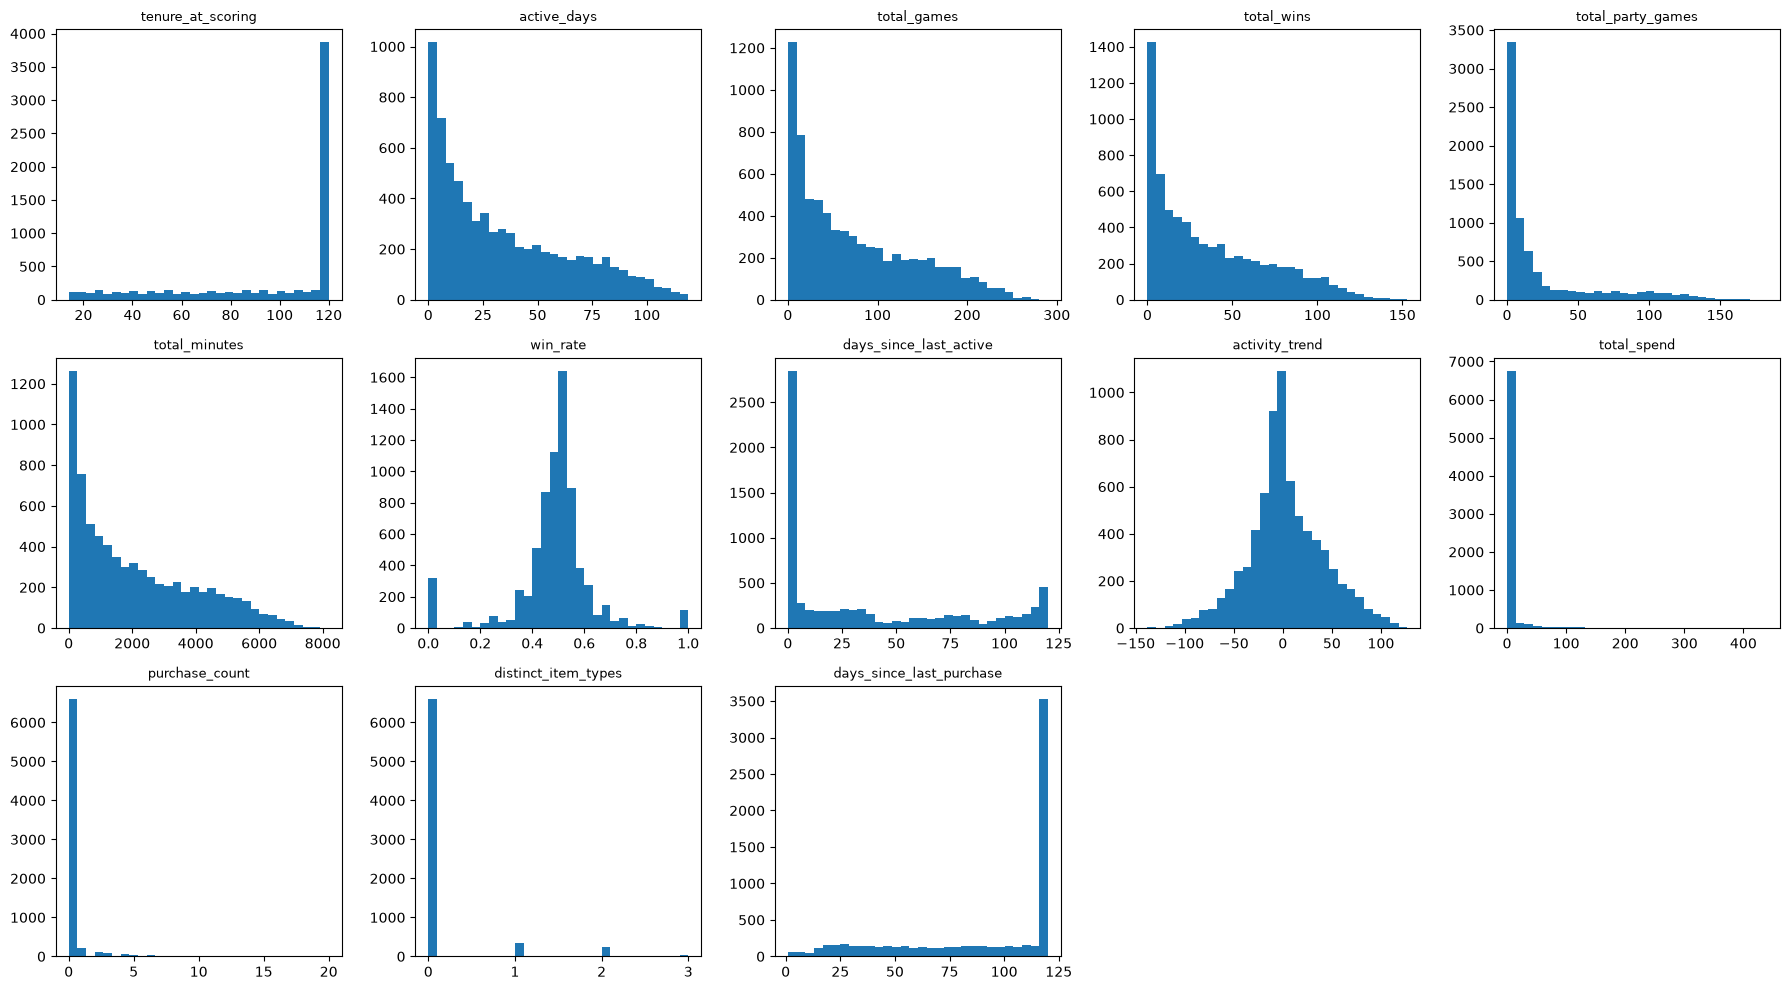

In [5]:
import matplotlib.pyplot as plt
fig, axes = plt.subplots(3, 5, figsize=(18, 10))
for ax, col in zip(axes.flat, numeric_cols):
    ax.hist(df[col], bins=30)
    ax.set_title(col, fontsize=9)
for ax in axes.flat[len(numeric_cols):]:
    ax.axis('off')
plt.tight_layout()
plt.show()

## Categorical distributions

In [6]:
for c in ['region', 'platform', 'acquisition_source']:
    print(c)
    print(df[c].value_counts(dropna=False))
    print()

region
region
EUW      2197
NaN      2132
BR       1130
KR       1086
LATAM     679
Name: count, dtype: int64

platform
platform
pc        5824
mobile    1400
Name: count, dtype: int64

acquisition_source
acquisition_source
organic            3604
paid_ads           2152
friend_referral    1468
Name: count, dtype: int64



## Label rate by category

Quick check for any categorical with an obviously different churn rate - informs the features step.

In [7]:
for c in ['region', 'platform', 'acquisition_source']:
    print(c)
    print(df.groupby(c, dropna=False)['label'].mean())
    print()

region
region
BR       0.659292
EUW      0.667729
KR       0.647330
LATAM    0.671576
NaN      0.674953
Name: label, dtype: float64

platform
platform
mobile    0.657857
pc        0.667754
Name: label, dtype: float64

acquisition_source
acquisition_source
friend_referral    0.555177
organic            0.695339
paid_ads           0.691914
Name: label, dtype: float64

